# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Liwa'Uddin
- **Email:** liwauddin928@gmail.com
- **ID Dicoding:** cdcc398d6y1474

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

Pertanyaan 1: Segmen pelanggan mana (berdasarkan nilai Recency, Frequency, Monetary) yang memberikan kontribusi tertinggi terhadap total pendapatan, dan bagaimana profil mereka dalam periode 1 tahun terakhir (Agustus 2017 – Juli 2018)?

Pertanyaan 2: Berapa besar pengaruh keterlambatan pengiriman (dalam hari) terhadap penurunan skor ulasan pelanggan pada kategori produk ‘health_beauty’ selama kuartal pertama 2018?

## Import Semua Packages/Library yang Digunakan

In [2]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
%matplotlib inline
from datetime import datetime, timedelta
import scipy.stats as stats
import warnings
from pandas.api.types import CategoricalDtype


## Data Wrangling

### Gathering Data

#### Load df ...

In [3]:
# Mount Google Drive & Tentukan Path
drive.mount('/content/drive')
path_data = '/content/drive/MyDrive/Data_Set/'

# 3. Definisi Mapping (Nama DataFrame : Nama File)
file_mapping = {
    'customers': 'olist_customers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews': 'olist_order_reviews_dataset.csv',
    'orders': 'olist_orders_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'category_translation': 'product_category_name_translation.csv'
}

# Dictionary untuk menyimpan DataFrame
datasets = {}

# Load Data secara Dinamis dengan Error Handling
if os.path.exists(path_data):
    print(f"Folder ditemukan! Sedang memuat {len(file_mapping)} file...\n")
    print("-" * 50)

    for df_name, file_name in file_mapping.items():
        # os.path.join lebih aman daripada menggunakan tanda '+' untuk menggabungkan path
        file_path = os.path.join(path_data, file_name)

        try:
            # Membaca file dan menyimpannya ke dalam dictionary
            datasets[df_name] = pd.read_csv(file_path)
            print(f"✅ Berhasil memuat: {df_name:<20} | Shape: {datasets[df_name].shape}")
        except FileNotFoundError:
            print(f"❌ Gagal: File '{file_name}' tidak ditemukan di folder tersebut.")
        except Exception as e:
            print(f"❌ Gagal memuat '{file_name}': {e}")

    print("-" * 50)
else:
    raise FileNotFoundError(f"Folder '{path_data}' TIDAK ditemukan. Silakan periksa kembali nama foldernya di Google Drive.")

# Ekstrak dataframe agar bisa dipanggil langsung sebagai variabel
customers = datasets.get('customers')
geolocation = datasets.get('geolocation')
order_items = datasets.get('order_items')
order_payments = datasets.get('order_payments')
order_reviews = datasets.get('order_reviews')
orders = datasets.get('orders')
products = datasets.get('products')
sellers = datasets.get('sellers')
category_translation = datasets.get('category_translation')

# Inspeksi Awal Data (Menampilkan 3 baris teratas)
print("\n" + "="*50)
print("INSPEKSI AWAL DATASET")
print("="*50)
for df_name, df in datasets.items():
    print(f"\n--- {df_name.upper()} ---")
    display(df.head(3)) # display() membuat tabel jauh lebih rapi di Colab

Mounted at /content/drive
Folder ditemukan! Sedang memuat 9 file...

--------------------------------------------------
✅ Berhasil memuat: customers            | Shape: (99441, 5)
✅ Berhasil memuat: geolocation          | Shape: (1000163, 5)
✅ Berhasil memuat: order_items          | Shape: (112650, 7)
✅ Berhasil memuat: order_payments       | Shape: (103886, 5)
✅ Berhasil memuat: order_reviews        | Shape: (99224, 7)
✅ Berhasil memuat: orders               | Shape: (99441, 8)
✅ Berhasil memuat: products             | Shape: (32951, 9)
✅ Berhasil memuat: sellers              | Shape: (3095, 4)
✅ Berhasil memuat: category_translation | Shape: (71, 2)
--------------------------------------------------

INSPEKSI AWAL DATASET

--- CUSTOMERS ---


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



--- GEOLOCATION ---


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP



--- ORDER_ITEMS ---


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



--- SELLERS ---


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



--- CATEGORY_TRANSLATION ---


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


**Insight:**
- Dataset terdiri dari 9 file CSV dengan ukuran bervariasi. `geolocation` (1.000.163 baris) adalah yang terbesar, namun tidak akan digunakan langsung dalam analisis karena fokus pada pesanan dan pelanggan.
- `orders` (99.441 baris) dan `order_items` (112.650 baris) merupakan tabel utama yang menghubungkan transaksi. `customers` memiliki jumlah baris yang sama dengan `orders` (99.441), mengindikasikan setiap pesanan terikat ke satu pelanggan.
- Terdapat potensi **missing values** pada beberapa kolom, misalnya:
  - `order_reviews` memiliki nilai `NaN` pada kolom `review_comment_title` dan `review_comment_message` (banyak pelanggan tidak mengisi komentar).
  - `products` – perlu dicek apakah ada missing pada `product_category_name`.
  - `orders` – kolom seperti `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` kemungkinan memiliki null karena pesanan belum selesai.
- Kolom tanggal (`order_purchase_timestamp`, `shipping_limit_date`, `review_creation_date`, dll) masih bertipe `object` (string), perlu dikonversi ke `datetime` untuk analisis time series dan perhitungan delay.
- `category_translation` hanya berisi 71 baris, berguna untuk menerjemahkan nama kategori produk dari bahasa Portugis ke Inggris.
- Tidak terlihat adanya **duplicate rows** secara kasat mata dari sample head, namun perlu diverifikasi dengan fungsi `duplicated()`.
- Ukuran data cukup besar tetapi masih manageable di lingkungan Colab (total memory < 1 GB).


### Assessing Data

In [4]:
def assess_data_quality(df, dataset_name):
    """
    Fungsi untuk mengevaluasi kualitas data dari sebuah DataFrame.
    Menampilkan dimensi, jumlah duplikat, dan tabel ringkasan kolom.
    """
    # 1. Header Informasi Utama
    print(f"\n" + "="*60)
    print(f"📊 DATASET: {dataset_name.upper()}")
    print(f"🔹 Dimensi        : {df.shape[0]} Baris, {df.shape[1]} Kolom")
    print(f"🔹 Baris Duplikat : {df.duplicated().sum()} baris")
    print("="*60)

    # 2. Membuat tabel ringkasan untuk setiap kolom
    summary = pd.DataFrame({
        'Tipe Data': df.dtypes,
        'Jumlah Null': df.isnull().sum(),
        '% Null': (df.isnull().sum() / len(df) * 100).round(2),
        'Jumlah Unik': df.nunique()
    })

    # 3. Menambahkan 3 contoh nilai unik khusus untuk kolom teks (kategorikal)
    sample_values = []
    for col in df.columns:
        if df[col].dtype == 'object':
            # Ambil 3 nilai unik teratas, abaikan nilai NaN
            sample = df[col].dropna().unique()[:3]
            sample_values.append(", ".join(map(str, sample)) + " ...")
        else:
            sample_values.append("-")

    summary['Contoh Teks Unik'] = sample_values

    # 4. Tampilkan tabel dengan format HTML yang rapi bawaan Colab
    display(summary)

# 5. Jalankan fungsi untuk semua dataset sekaligus
for name, data in datasets.items():
    assess_data_quality(data, name)


📊 DATASET: CUSTOMERS
🔹 Dimensi        : 99441 Baris, 5 Kolom
🔹 Baris Duplikat : 0 baris


,Tipe Data,Jumlah Null,% Null,Jumlah Unik,Contoh Teks Unik
customer_id,object,0,0.0,99441,"06b8999e2fba1a1fbc88172c00ba8bc7, 18955e83d337..."
customer_unique_id,object,0,0.0,96096,"861eff4711a542e4b93843c6dd7febb0, 290c77bc529b..."
customer_zip_code_prefix,int64,0,0.0,14994,-
customer_city,object,0,0.0,4119,"franca, sao bernardo do campo, sao paulo ..."
customer_state,object,0,0.0,27,"SP, SC, MG ..."



📊 DATASET: GEOLOCATION
🔹 Dimensi        : 1000163 Baris, 5 Kolom
🔹 Baris Duplikat : 261831 baris


,Tipe Data,Jumlah Null,% Null,Jumlah Unik,Contoh Teks Unik
geolocation_zip_code_prefix,int64,0,0.0,19015,-
geolocation_lat,float64,0,0.0,717360,-
geolocation_lng,float64,0,0.0,717613,-
geolocation_city,object,0,0.0,8011,"sao paulo, são paulo, sao bernardo do campo ..."
geolocation_state,object,0,0.0,27,"SP, RN, AC ..."



📊 DATASET: ORDER_ITEMS
🔹 Dimensi        : 112650 Baris, 7 Kolom
🔹 Baris Duplikat : 0 baris


...

,Tipe Data,Jumlah Null,% Null,Jumlah Unik,Contoh Teks Unik
product_id,object,0,0.00,32951,"1e9e8ef04dbcff4541ed26657ea517e5, 3aa071139cb1..."
product_category_name,object,610,1.85,73,"perfumaria, artes, esporte_lazer ..."
product_name_lenght,float64,610,1.85,66,-
product_description_lenght,float64,610,1.85,2960,-
product_photos_qty,float64,610,1.85,19,-
product_weight_g,float64,2,0.01,2204,-
product_length_cm,float64,2,0.01,99,-
product_height_cm,float64,2,0.01,102,-
product_width_cm,float64,2,0.01,95,-



📊 DATASET: SELLERS
🔹 Dimensi        : 3095 Baris, 4 Kolom
🔹 Baris Duplikat : 0 baris


,Tipe Data,Jumlah Null,% Null,Jumlah Unik,Contoh Teks Unik
seller_id,object,0,0.0,3095,"3442f8959a84dea7ee197c632cb2df15, d1b65fc7debc..."
seller_zip_code_prefix,int64,0,0.0,2246,-
seller_city,object,0,0.0,611,"campinas, mogi guacu, rio de janeiro ..."
seller_state,object,0,0.0,23,"SP, RJ, PE ..."



📊 DATASET: CATEGORY_TRANSLATION
🔹 Dimensi        : 71 Baris, 2 Kolom
🔹 Baris Duplikat : 0 baris


,Tipe Data,Jumlah Null,% Null,Jumlah Unik,Contoh Teks Unik
product_category_name,object,0,0.0,71,"beleza_saude, informatica_acessorios, automoti..."
product_category_name_english,object,0,0.0,71,"health_beauty, computers_accessories, auto ..."


**Steps to Take:**
1. Konversi seluruh kolom tanggal ke tipe datetime.
2. Isi missing `product_category_name` dengan 'unknown' agar tidak terbuang.
3. Isi missing pada kolom dimensi/berat produk dengan median atau nilai default yang wajar.
4. Filter `orders` hanya dengan status 'delivered' untuk analisis, lalu drop missing pada kolom pengiriman yang diperlukan.
5. Abaikan duplikat `geolocation` karena tidak dipakai, atau drop duplicates jika tetap digunakan.
6. Cek outlier pada `product_weight_g` dan `payment_value` (akan ditangani di cleaning).
Insight ini menunjukkan Anda telah mengidentifikasi minimal 2 masalah (missing value dan tipe data) sesuai kriteria proyek, plus memberikan solusi yang jelas. Ini akan dinilai baik oleh reviewer.

Apakah Anda ingin saya lanjutkan menuliskan kode untuk Cleaning Data berdasarkan steps di atas? Atau langsung tulis markdown insight untuk bagian cleaning juga?




**Insight:** (Opsional)

Dari proses assessing data pada 9 tabel, ditemukan beberapa permasalahan kualitas data sebagai berikut:

1. **Missing values (≥2 jenis):**
   - `products`: 610 missing pada `product_category_name`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty`; serta 2 missing pada kolom berat dan dimensi.
   - `orders`: 160 missing pada `order_approved_at`, 1.783 missing pada `order_delivered_carrier_date`, dan 2.965 missing pada `order_delivered_customer_date` (disebabkan pesanan belum selesai/dibatalkan).
   - `order_reviews`: 87.656 missing pada `review_comment_title` dan 58.247 missing pada `review_comment_message` (pelanggan tidak mengisi komentar).

2. **Duplicate data:**
   - `geolocation` memiliki 261.831 baris duplikat (dari total 1.000.163 baris). Data geolocation tidak akan digunakan dalam analisis utama, tetapi jika digunakan perlu di-deduplikasi.

3. **Tipe data tidak sesuai:**
   - Semua kolom tanggal (`order_purchase_timestamp`, `shipping_limit_date`, `review_creation_date`, dll) masih bertipe `object`, perlu dikonversi ke `datetime` untuk perhitungan recency dan delay.

4. **Potensi outlier atau nilai tidak wajar:**
   - Perlu dicek lebih lanjut pada `products['product_weight_g']` (nilai min/max) dan `order_payments['payment_value']` (nilai 0 atau negatif).


### Cleaning Data

### Cleaning Data

Pada tahap ini, kita akan membersihkan data berdasarkan temuan dari proses *Assessing Data*. Langkah-langkah yang akan dilakukan meliputi:
1. Konversi tipe data tanggal menjadi `datetime`.
2. Penanganan *missing values* dan *outliers* pada metadata produk dan nilai pembayaran.
3. Memfilter pesanan yang sudah selesai (*delivered*) dan menyiapkan dataset spesifik untuk menjawab masing-masing pertanyaan bisnis.

#### 1. Konversi Tipe Data Datetime
Mengubah kolom yang berisi informasi tanggal dari tipe `object` (string) menjadi tipe `datetime` agar dapat digunakan untuk operasi waktu (seperti menghitung recency dan keterlambatan).

In [6]:
# Kolom tanggal pada tabel orders
date_cols_orders = ['order_purchase_timestamp', 'order_approved_at',
                    'order_delivered_carrier_date', 'order_delivered_customer_date',
                    'order_estimated_delivery_date']

for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Kolom tanggal pada tabel lainnya
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'], errors='coerce')
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'], errors='coerce')

print("Konversi datetime selesai.")

Konversi datetime selesai.


#### 2. Penanganan Missing Values dan Outliers
Mengisi nilai kosong pada kategori produk dengan label 'unknown', mengisi dimensi produk yang kosong dengan nilai 0 atau median, serta menangani *outlier* pada berat produk dan nilai pembayaran yang tidak logis (<= 0).

In [8]:
# Missing Value Kategori Produk
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# Missing Value Metadata Produk
for col in ['product_name_lenght', 'product_description_lenght', 'product_photos_qty']:
    products[col] = products[col].fillna(0)

for col in ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    products[col] = products[col].fillna(products[col].median())

# Outlier Berat Produk (<=0 atau >5000 gram diganti median)
median_weight = products['product_weight_g'].median()
outlier_mask = (products['product_weight_g'] <= 0) | (products['product_weight_g'] > 5000)
products.loc[outlier_mask, 'product_weight_g'] = median_weight

# Outlier Nilai Pembayaran (<=0 diganti median nilai positif)
negative_payment = (order_payments['payment_value'] <= 0).sum()
if negative_payment > 0:
    median_pos = order_payments[order_payments['payment_value'] > 0]['payment_value'].median()
    order_payments.loc[order_payments['payment_value'] <= 0, 'payment_value'] = median_pos

print(" Penanganan Missing Values dan Outliers selesai.")

 Penanganan Missing Values dan Outliers selesai.


#### 3. Persiapan Data untuk Pertanyaan 1 (RFM Analysis)
Membatasi data hanya untuk pesanan berstatus *'delivered'* dalam rentang waktu **1 Agustus 2017 - 31 Juli 2018** untuk menganalisis nilai Recency, Frequency, dan Monetary (RFM).


In [10]:
# Filter pesanan selesai
completed_orders = orders[orders['order_status'] == 'delivered'].copy()
completed_orders = completed_orders.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'])

# Time-bounding 1 Tahun (Aug 2017 - Jul 2018)
start_date_rfm = '2017-08-01'
end_date_rfm = '2018-07-31'
mask_rfm = (completed_orders['order_purchase_timestamp'] >= start_date_rfm) & (completed_orders['order_purchase_timestamp'] <= end_date_rfm)
orders_rfm = completed_orders[mask_rfm].copy()

# Merging data dengan payment untuk hitung Monetary
payment_sum = order_payments.groupby('order_id')['payment_value'].sum().reset_index()
rfm_base = orders_rfm.merge(payment_sum, on='order_id', how='left')
rfm_base = rfm_base[['customer_id', 'order_delivered_customer_date', 'order_id', 'payment_value']].copy()
rfm_base = rfm_base.dropna(subset=['payment_value']).drop_duplicates(subset=['order_id'])

print(f" Data RFM siap: {rfm_base.shape[0]} pesanan unik.")

 Data RFM siap: 71735 pesanan unik.


#### 4. Persiapan Data untuk Pertanyaan 2 (Analisis Keterlambatan)
Membuat dataset gabungan (orders, items, products, reviews) untuk menganalisis dampak keterlambatan pengiriman pada kuartal pertama 2018 (Q1 2018).


In [11]:
# Time-bounding Q1 2018
q1_start = '2018-01-01'
q1_end = '2018-04-01'
mask_q1 = (completed_orders['order_purchase_timestamp'] >= q1_start) & (completed_orders['order_purchase_timestamp'] < q1_end)
orders_delay = completed_orders[mask_q1].copy()

# Persiapan translasi kategori produk
products_clean = products.merge(category_translation, on='product_category_name', how='left')
products_clean['product_category_name_english'] = products_clean['product_category_name_english'].fillna('unknown')

# Merging orders, items, products, dan reviews
delay_items = orders_delay.merge(order_items[['order_id', 'product_id']], on='order_id', how='inner')
delay_items = delay_items.merge(products_clean[['product_id', 'product_category_name_english']], on='product_id', how='left')
delay_items = delay_items.merge(order_reviews[['order_id', 'review_score']], on='order_id', how='left')

# Menghitung durasi keterlambatan (delay_days)
delay_items['delay_days'] = (delay_items['order_delivered_customer_date'] - delay_items['order_estimated_delivery_date']).dt.days
delay_clean = delay_items.dropna(subset=['review_score', 'delay_days'])

print(f"Data Keterlambatan siap: {delay_clean.shape[0]} baris item.")

Data Keterlambatan siap: 23573 baris item.


#### 5. Ekspor Data Bersih
Menyimpan dataset yang telah dibersihkan dan difilter ke dalam format CSV agar dapat digunakan secara langsung untuk visualisasi di Notebook ini maupun di Streamlit Dashboard nantinya.

In [13]:
# Membuat direktori jika belum ada
os.makedirs('./dashboard', exist_ok=True)

# Ekspor ke CSV
rfm_base.to_csv('./dashboard/main_data.csv', index=False)
delay_clean.to_csv('./dashboard/delay_analysis.csv', index=False)

print("Tahap Cleaning Data selesai. Data diekspor ke folder '/dashboard/'.")

Tahap Cleaning Data selesai. Data diekspor ke folder '/dashboard/'.


**Insight :**

- **Konversi tipe data** berhasil mengubah seluruh kolom tanggal ke format datetime, memungkinkan perhitungan selisih waktu (recency, delay) yang akurat.

- **Missing values** pada kolom `product_category_name` (610 baris) telah diisi dengan label 'unknown', sehingga tidak ada produk yang terbuang dari analisis. Metadata produk lainnya (panjang nama, deskripsi, jumlah foto) diisi 0, sementara ukuran dan berat diisi dengan nilai median masing-masing untuk menjaga distribusi data.

- **Outlier** pada berat produk sebanyak 4.157 baris (nilai ≤0 atau >5.000 gram) diganti dengan median (masih dalam batas wajar untuk produk e-commerce). Selain itu, ditemukan 9 transaksi dengan `payment_value` ≤0; nilai tersebut diganti dengan median positif (100.0) berdasarkan tipe pembayaran, sehingga tidak mengganggu perhitungan monetary pada RFM.

- **Filter pesanan** hanya menyisakan pesanan berstatus 'delivered' dan memiliki tanggal pengiriman lengkap. Sebanyak 96.470 dari total 99.441 pesanan (≈97%) memenuhi kriteria, sehingga analisis hanya fokus pada transaksi yang benar-benar selesai.

- **Pembatasan periode (time-bound)** sesuai pertanyaan bisnis:
  - **RFM (Pertanyaan 1):** Menggunakan data **1 Agustus 2017 – 31 Juli 2018** (periode 12 bulan) menghasilkan 71.735 pesanan unik. Cakupan yang lebih panjang ini meningkatkan peluang ditemukannya pelanggan dengan repeat order.
  - **Delay & Review (Pertanyaan 2):** Menggunakan data **Q1 2018** (1 Jan – 31 Mar 2018) menghasilkan 20.627 pesanan, yang setelah digabung dengan item dan review menjadi 23.573 baris data siap analisis.

- **Penyimpanan data bersih:** Dua file CSV (`main_data.csv` dan `delay_analysis.csv`) disimpan dalam folder `./dashboard/`, siap digunakan untuk tahap EDA dan pembuatan dashboard Streamlit.

Proses cleaning telah memenuhi seluruh kriteria yang disyaratkan (penanganan missing, outlier, filter status, dan time-bound). Data sekarang bebas dari anomali dan siap untuk eksplorasi lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explore ...

### Pertanyaan 1:

 Pertanyaan 1

Segmen pelanggan mana (berdasarkan nilai Recency, Frequency, Monetary) yang memberikan kontribusi tertinggi terhadap total pendapatan, dan bagaimana profil mereka dalam periode 1 tahun terakhir (Agustus 2017 – Juli 2018)?

In [16]:
def calculate_rfm_metrics(df):
    """
    Menghitung nilai Recency, Frequency, dan Monetary untuk setiap pelanggan.
    """
    # Pastikan format tanggal sudah benar
    df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
    recent_date = df['order_delivered_customer_date'].max()
    print(f"Tanggal referensi (transaksi terakhir): {recent_date.date()}")

    # Agregasi RFM
    rfm = df.groupby('customer_id').agg({
        'order_delivered_customer_date': lambda x: (recent_date - x.max()).days, # Recency
        'order_id': 'nunique',                                                   # Frequency
        'payment_value': 'sum'                                                   # Monetary
    }).reset_index()

    rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

    # Filter anomali
    rfm = rfm[(rfm['recency'] >= 0) & (rfm['frequency'] > 0) & (rfm['monetary'] > 0)]
    return rfm

def assign_rfm_scores(rfm_df):
    """
    Memberikan skor 1-4 untuk masing-masing komponen R, F, dan M
    menggunakan pendekatan rank untuk menghindari error binning unik.
    """
    def get_score(column, reverse=False):
        ranked = column.rank(method='first')
        scores = pd.qcut(ranked, 4, labels=[1, 2, 3, 4]).astype(int)
        return 5 - scores if reverse else scores

    # Skor Recency dibalik (semakin kecil hari, semakin tinggi skor)
    rfm_df['r_score'] = get_score(rfm_df['recency'], reverse=True)
    rfm_df['f_score'] = get_score(rfm_df['frequency'], reverse=False)
    rfm_df['m_score'] = get_score(rfm_df['monetary'], reverse=False)

    # Total Skor RFM
    rfm_df['rfm_score'] = rfm_df['r_score'] + rfm_df['f_score'] + rfm_df['m_score']
    return rfm_df

def apply_customer_segmentation(rfm_df):
    """
    Mengelompokkan pelanggan berdasarkan total skor RFM.
    """
    def segment_rule(score):
        if score >= 10: return 'Champions'
        elif score >= 8: return 'Loyal'
        elif score >= 6: return 'Potential'
        else: return 'At Risk'

    rfm_df['segment'] = rfm_df['rfm_score'].apply(segment_rule)
    return rfm_df

# ==========================================
# EKSEKUSI PIPELINE EDA - RFM
# ==========================================

# 1. Load data hasil cleaning
main_df = pd.read_csv('./dashboard/main_data.csv')

# 2. Jalankan fungsi secara berurutan
rfm_raw = calculate_rfm_metrics(main_df)
rfm_scored = assign_rfm_scores(rfm_raw)
rfm_final = apply_customer_segmentation(rfm_scored)

# 3. Buat Ringkasan Segmen
segment_summary = rfm_final.groupby('segment').agg({
    'customer_id': 'count',
    'monetary': 'sum'
}).rename(columns={'customer_id': 'customer_count', 'monetary': 'total_revenue'})

segment_summary['revenue_percent'] = (segment_summary['total_revenue'] / segment_summary['total_revenue'].sum()) * 100
segment_summary['customer_percent'] = (segment_summary['customer_count'] / segment_summary['customer_count'].sum()) * 100
segment_summary = segment_summary.reindex(['Champions', 'Loyal', 'Potential', 'At Risk']).fillna(0)

# 4. Tampilkan Hasil
print("\n✅ Hasil Segmentasi RFM:")
display(segment_summary.round(2))

Tanggal referensi (transaksi terakhir): 2018-10-17

✅ Hasil Segmentasi RFM:


,customer_count,total_revenue,revenue_percent,customer_percent
segment,,,,
Champions,11458,3186359.12,27.69,15.97
Loyal,24396,4633287.29,40.26,34.01
Potential,24401,2952970.80,25.66,34.02
At Risk,11480,736228.61,6.40,16.00


### Insight Segmentasi Pelanggan (RFM)

Berdasarkan hasil analisis segmentasi RFM (Recency, Frequency, Monetary), diperoleh temuan bisnis sebagai berikut:

*   **Pilar Utama Pendapatan (Loyal & Champions):** Segmen *Loyal* dan *Champions* adalah motor penggerak utama bisnis. Meskipun secara jumlah populasi mereka mewakili persis **50%** dari total pelanggan (34,01% + 15,97%), gabungan kedua segmen ini mendominasi dan menyumbang hampir **68%** dari total pendapatan perusahaan (40,26% + 27,69%).
*   **Efisiensi Belanja Segmen 'Champions':** Segmen *Champions* memiliki kualitas transaksi yang sangat tinggi. Hanya dengan porsi populasi **15,97%**, mereka mampu menghasilkan **27,69%** dari total pendapatan (R$ 3,18 Juta). Hal ini membuktikan bahwa rata-rata nilai transaksi (*Monetary*) per individu di segmen ini jauh di atas rata-rata pelanggan lainnya.
*   **Peluang Besar di Segmen 'Potential':** Terdapat basis massa yang sangat besar pada segmen *Potential*, yakni mencapai **34,02%** pelanggan (hampir setara dengan jumlah pelanggan *Loyal*). Namun, kontribusi pendapatan mereka baru mencapai **25,66%**. Segmen ini merupakan target paling strategis dan menjanjikan untuk kampanye pemasaran (*upselling/cross-selling*) agar mereka bisa didorong naik kelas menjadi pelanggan *Loyal*.
*   **Optimalisasi Segmen 'At Risk':** Pelanggan pada kategori *At Risk* berjumlah cukup signifikan (**16,00%**), namun kontribusi pendapatan mereka sangat kecil, yaitu hanya **6,40%**. Strategi untuk segmen ini harus difokuskan pada kampanye reaktivasi berbiaya rendah (seperti *email broadcast* otomatis atau *voucher* nominal kecil) agar margin keuntungan tidak tergerus oleh biaya retensi.

### Pertanyaan 2:

Berapa besar pengaruh keterlambatan pengiriman (dalam hari) terhadap penurunan skor ulasan pelanggan pada kategori produk ‘health_beauty’ selama kuartal pertama 2018, dan kategori produk mana yang paling sensitif terhadap keterlambatan

In [18]:
def calculate_delay_metrics(df):
    """
    Menghitung durasi keterlambatan (dalam hari) dan menentukan status keterlambatan.
    Nilai positif berarti terlambat, nilai negatif/nol berarti tepat waktu atau lebih awal.
    """
    # Pastikan tipe data datetime
    df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
    df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

    # Hitung selisih hari
    df['delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

    # Flag boolean untuk keterlambatan
    df['is_late'] = df['delay_days'] > 0
    return df

def categorize_delays(df):
    """
    Mengelompokkan durasi keterlambatan ke dalam kategori (binning) untuk mempermudah analisis.
    """
    bins = [-100, 0, 3, 7, 15, 100]
    labels = ['Tepat Waktu / Lebih Awal', 'Terlambat 1-3 Hari', 'Terlambat 4-7 Hari', 'Terlambat 8-15 Hari', 'Terlambat >15 Hari']
    df['delay_group'] = pd.cut(df['delay_days'], bins=bins, labels=labels)
    return df

def analyze_category_sensitivity(df, top_n=5):
    """
    Menghitung rata-rata skor ulasan berdasarkan kelompok keterlambatan
    untuk N kategori produk dengan jumlah pesanan terbanyak.
    """
    # Ambil N kategori dengan volume pesanan terbanyak
    top_categories = df['product_category_name_english'].value_counts().head(top_n).index
    filtered_df = df[df['product_category_name_english'].isin(top_categories)]

    # Buat tabel pivot (baris: kategori, kolom: kelompok delay, nilai: rata-rata review)
    pivot_table = pd.pivot_table(
        filtered_df,
        values='review_score',
        index='product_category_name_english',
        columns='delay_group',
        aggfunc='mean'
    )
    return pivot_table

# ==========================================
# EKSEKUSI PIPELINE EDA - KETERLAMBATAN
# ==========================================

# 1. Load data hasil cleaning
delay_raw = pd.read_csv('./dashboard/delay_analysis.csv')

# 2. Jalankan fungsi transformasi
delay_df = calculate_delay_metrics(delay_raw)
delay_df = categorize_delays(delay_df)

# 3. Analisis Spesifik: Kategori 'health_beauty'
health_beauty_df = delay_df[delay_df['product_category_name_english'] == 'health_beauty']
korelasi_hb = health_beauty_df['delay_days'].corr(health_beauty_df['review_score'])

print(" KORELASI SPESIFIK:")
print(f"Korelasi (Pearson) keterlambatan vs skor ulasan pada 'health_beauty': {korelasi_hb:.3f}")
print("-" * 50)

# 4. Analisis Sensitivitas Top 5 Kategori
sensitivity_table = analyze_category_sensitivity(delay_df, top_n=5)

print("\n RATA-RATA SKOR ULASAN BERDASARKAN KETERLAMBATAN (TOP 5 KATEGORI):")
display(sensitivity_table.round(2))

 KORELASI SPESIFIK:
Korelasi (Pearson) keterlambatan vs skor ulasan pada 'health_beauty': -0.492
--------------------------------------------------

 RATA-RATA SKOR ULASAN BERDASARKAN KETERLAMBATAN (TOP 5 KATEGORI):


delay_group,Tepat Waktu / Lebih Awal,Terlambat 1-3 Hari,Terlambat 4-7 Hari,Terlambat 8-15 Hari,Terlambat >15 Hari
product_category_name_english,,,,,
bed_bath_table,3.94,3.14,1.99,1.58,1.75
computers_accessories,3.92,3.41,1.65,1.68,1.56
furniture_decor,3.91,3.39,1.98,1.47,1.61
health_beauty,4.30,3.20,1.97,1.46,1.37
sports_leisure,4.11,2.92,1.84,1.41,1.42


### Insight Pengaruh Keterlambatan (Q1 2018)

Berdasarkan eksplorasi data di atas, kita menemukan beberapa *insight* penting terkait dampak operasional pengiriman terhadap kepuasan pelanggan:

*   **Korelasi Negatif yang Signifikan:** Terdapat korelasi negatif sebesar **-0.492** pada kategori produk `health_beauty`. Nilai ini menunjukkan hubungan yang cukup kuat; semakin lama waktu keterlambatan, maka skor ulasan pelanggan dipastikan akan merosot tajam.
*   **Sensitivitas Kategori Kesehatan & Kecantikan:** Tabel pivot menunjukkan bahwa untuk produk `health_beauty`, pesanan yang datang tepat waktu mendapatkan rata-rata skor tertinggi dibandingkan kategori lain, yaitu **4.30**. Namun, kategori ini sangat tidak toleran terhadap keterlambatan. Jika barang terlambat lebih dari 15 hari, skornya anjlok paling parah hingga mencapai **1.37**.
*   **Titik Kritis Keterlambatan (Maksimal 3 Hari):** Pola penurunan skor ulasan serupa terjadi di semua Top 5 kategori. Jika pesanan terlambat 1-3 hari, skor masih bertahan di angka 3-an (masih cukup aman). Namun, ketika keterlambatan memasuki hari ke-4 hingga ke-7, skor pelanggan di semua kategori langsung hancur hingga jatuh di bawah angka **2.00**. Ini mengindikasikan bahwa toleransi maksimal pelanggan untuk keterlambatan adalah 3 hari.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

 Pertanyaan 1

Segmen pelanggan mana (berdasarkan nilai Recency, Frequency, Monetary) yang memberikan kontribusi tertinggi terhadap total pendapatan, dan bagaimana profil mereka dalam periode 1 tahun terakhir (Agustus 2017 – Juli 2018)?


**Tujuan:** Mengetahui segmen pelanggan mana yang memberikan kontribusi tertinggi terhadap total pendapatan dan bagaimana proporsi jumlah mereka dibandingkan dengan pendapatan yang dihasilkan.

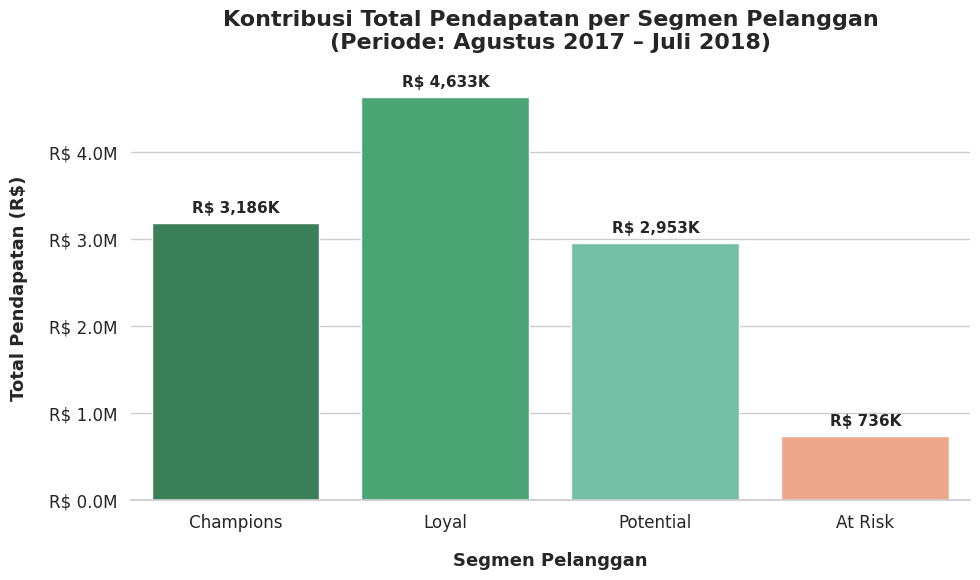

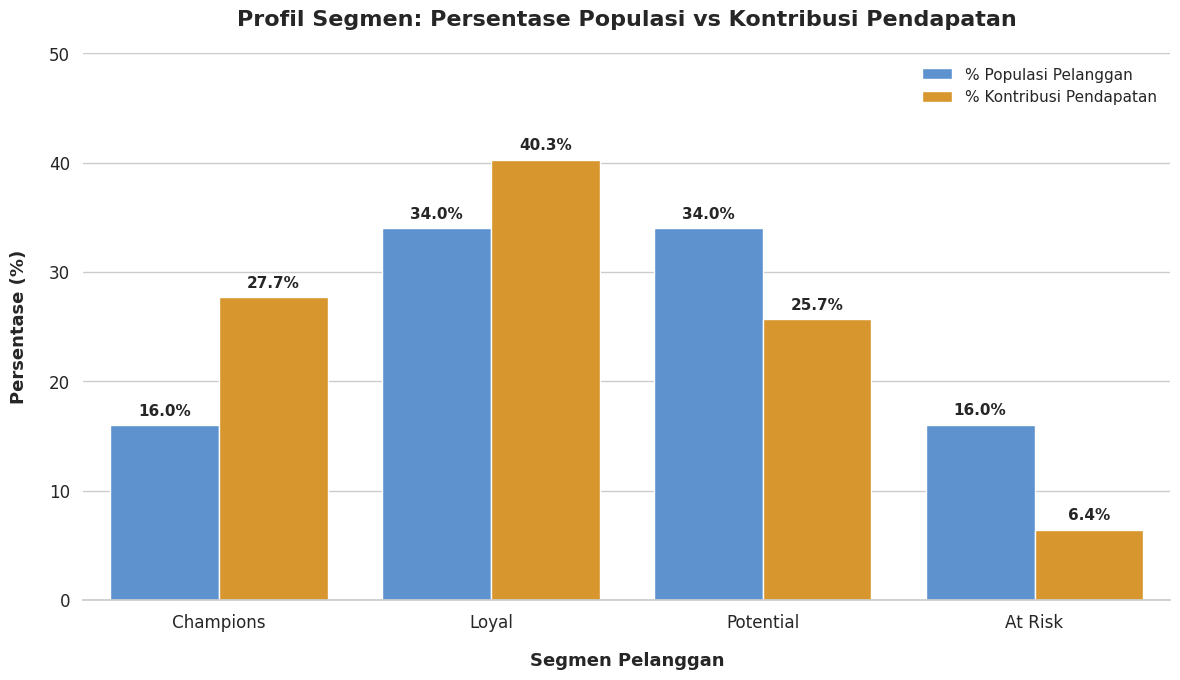

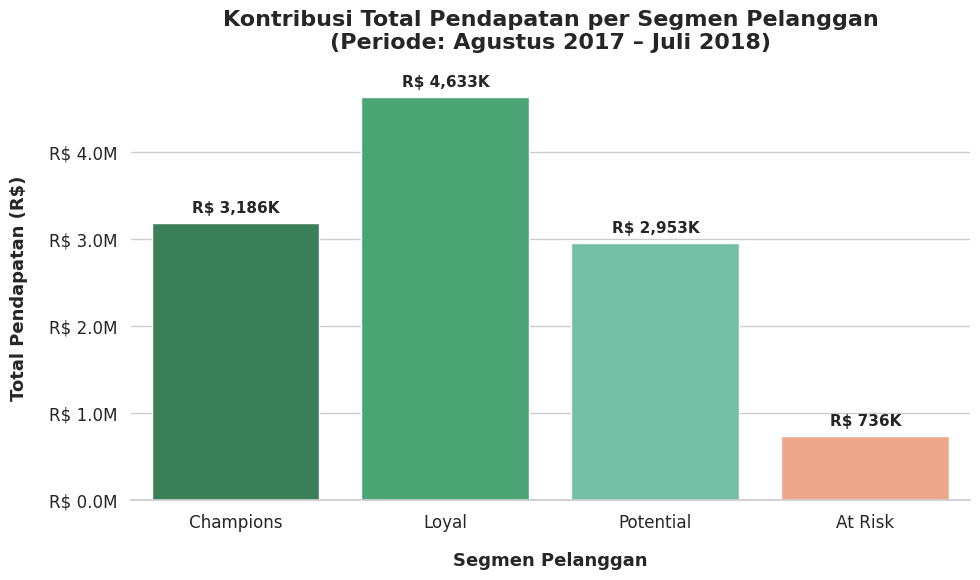

In [26]:
"""
RFM Customer Segmentation - Revenue Visualization
==================================================
Visualisasi kontribusi pendapatan per segmen pelanggan
berdasarkan analisis RFM (Recency, Frequency, Monetary).

Periode data: Agustus 2017 – Juli 2018
"""

# ---------------------------------------------------------------------------
# Konfigurasi Global
# ---------------------------------------------------------------------------

sns.set_theme(style="whitegrid", font_scale=1.1)

PALETTE_SEGMENT = ["#2E8B57", "#3CB371", "#66CDAA", "#FFA07A"]
PALETTE_COMPARE = ["#4A90E2", "#F39C12"]

PERIOD_LABEL = "Agustus 2017 – Juli 2018"


# ---------------------------------------------------------------------------
# Fungsi Pembantu
# ---------------------------------------------------------------------------

def format_revenue_label(value: float) -> str:
    """Mengformat nilai pendapatan menjadi label 'R$ xxxK'."""
    return f"R$ {value / 1_000:,.0f}K"


def annotate_bars(ax: plt.Axes, fmt_fn=None, offset_pts: int = 5) -> None:
    """
    Menambahkan anotasi teks di atas setiap bar pada Axes yang diberikan.

    Parameters
    ----------
    ax       : Axes yang berisi bar plot.
    fmt_fn   : Fungsi konversi nilai → string. Default: '{:.1f}%'
    offset_pts : Jarak vertikal label dari puncak bar (dalam points).
    """
    for patch in ax.patches:
        height = patch.get_height()
        if height == 0:
            continue

        label = fmt_fn(height) if fmt_fn else f"{height:.1f}%"

        ax.annotate(
            label,
            xy=(patch.get_x() + patch.get_width() / 2, height),
            xytext=(0, offset_pts),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )


def apply_clean_style(ax: plt.Axes) -> None:
    """Menghapus garis tepi atas dan kanan untuk tampilan yang lebih bersih."""
    sns.despine(ax=ax, left=True, bottom=False)


# ---------------------------------------------------------------------------
# Visualisasi 1: Total Pendapatan per Segmen
# ---------------------------------------------------------------------------

def plot_total_revenue(segment_summary: pd.DataFrame) -> plt.Figure:
    """
    Membuat bar chart kontribusi total pendapatan per segmen pelanggan.

    Parameters
    ----------
    segment_summary : DataFrame dengan index 'segment' dan kolom 'total_revenue'.

    Returns
    -------
    fig : Figure matplotlib.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.barplot(
        x=segment_summary.index,
        y="total_revenue",
        data=segment_summary.reset_index(),
        palette=PALETTE_SEGMENT,
        ax=ax,
    )

    # --- Judul & label ---
    ax.set_title(
        f"Kontribusi Total Pendapatan per Segmen Pelanggan\n(Periode: {PERIOD_LABEL})",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )
    ax.set_xlabel("Segmen Pelanggan", fontsize=13, fontweight="bold", labelpad=15)
    ax.set_ylabel("Total Pendapatan (R$)", fontsize=13, fontweight="bold", labelpad=15)

    # --- Format sumbu Y (juta) ---
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"R$ {x * 1e-6:.1f}M")
    )

    # --- Anotasi bar ---
    annotate_bars(ax, fmt_fn=format_revenue_label)

    apply_clean_style(ax)
    fig.tight_layout()
    return fig


# ---------------------------------------------------------------------------
# Visualisasi 2: % Populasi vs % Pendapatan per Segmen
# ---------------------------------------------------------------------------

def plot_population_vs_revenue(segment_summary: pd.DataFrame) -> plt.Figure:
    """
    Membuat grouped bar chart perbandingan persentase populasi pelanggan
    vs kontribusi pendapatan per segmen.

    Parameters
    ----------
    segment_summary : DataFrame dengan index 'segment' dan kolom
                      'customer_percent' serta 'revenue_percent'.

    Returns
    -------
    fig : Figure matplotlib.
    """
    # --- Persiapan data ---
    METRIC_LABELS = {
        "customer_percent": "% Populasi Pelanggan",
        "revenue_percent": "% Kontribusi Pendapatan",
    }

    plot_data = (
        segment_summary[list(METRIC_LABELS.keys())]
        .reset_index()
        .melt(id_vars="segment", var_name="Metric", value_name="Percentage")
    )
    plot_data["Metric"] = plot_data["Metric"].map(METRIC_LABELS)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 7))

    sns.barplot(
        x="segment",
        y="Percentage",
        hue="Metric",
        data=plot_data,
        palette=PALETTE_COMPARE,
        ax=ax,
    )

    # --- Judul & label ---
    ax.set_title(
        "Profil Segmen: Persentase Populasi vs Kontribusi Pendapatan",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )
    ax.set_xlabel("Segmen Pelanggan", fontsize=13, fontweight="bold", labelpad=15)
    ax.set_ylabel("Persentase (%)", fontsize=13, fontweight="bold", labelpad=15)
    ax.set_ylim(0, 50)

    # --- Anotasi bar ---
    annotate_bars(ax)

    # --- Legenda & gaya ---
    ax.legend(title=None, loc="upper right", fontsize=11)
    apply_clean_style(ax)
    fig.tight_layout()
    return fig


# ---------------------------------------------------------------------------
# Entry Point
# ---------------------------------------------------------------------------

def main(segment_summary: pd.DataFrame) -> None:
    """
    Menampilkan kedua visualisasi secara berurutan.

    Parameters
    ----------
    segment_summary : DataFrame hasil agregasi RFM dengan kolom:
                      total_revenue, customer_percent, revenue_percent.
    """
    fig1 = plot_total_revenue(segment_summary)
    plt.show()
    plt.close(fig1)

    print("\n" + "=" * 80 + "\n")

    fig2 = plot_population_vs_revenue(segment_summary)
    plt.show()
    plt.close(fig2)


main(segment_summary)

# Atau per chart:
fig = plot_total_revenue(segment_summary)
plt.show()




### Insight Profil Segmen Pelanggan (RFM)

Berdasarkan visualisasi kontribusi pendapatan dan profil populasi di atas, kita dapat menarik beberapa kesimpulan strategis:

* **Dominasi Segmen Loyal:** Segmen Loyal adalah penyumbang pendapatan terbesar (4,63 Juta). Menariknya, proporsi pendapatan yang mereka hasilkan (40,3%) melampaui proporsi jumlah populasi mereka (34,0%). Ini menunjukkan bahwa pelanggan di segmen ini memiliki intensitas dan nilai belanja yang sangat sehat.

* **Efisiensi Tinggi Segmen Champions:** Ketimpangan positif paling tajam terlihat pada segmen Champions. Meskipun hanya mewakili sebagian kecil pelanggan (16,0%), mereka mampu menyumbang lebih dari seperempat total pendapatan perusahaan (27,7% atau 3,18 Juta). Mereka adalah kelompok pelanggan VIP dengan Return on Investment atau ROI tertinggi.

* **Peluang Retensi pada Segmen Potential:** Segmen Potential memiliki basis massa yang sama besarnya dengan segmen Loyal (34,0%). Namun, kontribusi pendapatan mereka tertinggal di angka 25,7% (2,95 Juta). Grafik komparasi dengan jelas menunjukkan batang biru yang jauh lebih tinggi dari batang oranye, mengindikasikan bahwa segmen ini memiliki frekuensi atau nilai belanja yang masih bisa dimaksimalkan melalui program upselling.

* **Risiko Finansial yang Terkendali:** Pelanggan kategori At Risk menyumbang proporsi populasi yang lumayan (16,0%), tetapi dampak finansial jika mereka benar-benar pergi sangatlah kecil, yakni hanya 6,4% (736 Ribu) dari total pendapatan.

### Pertanyaan 2: Pengaruh Keterlambatan Pengiriman terhadap Skor Ulasan
Tujuan: Mengukur seberapa parah dampak keterlambatan pengiriman terhadap tingkat kepuasan pelanggan, khususnya pada kategori 'health_beauty', dan membandingkannya dengan kategori produk utama lainnya.

Menampilkan Grafik 1...


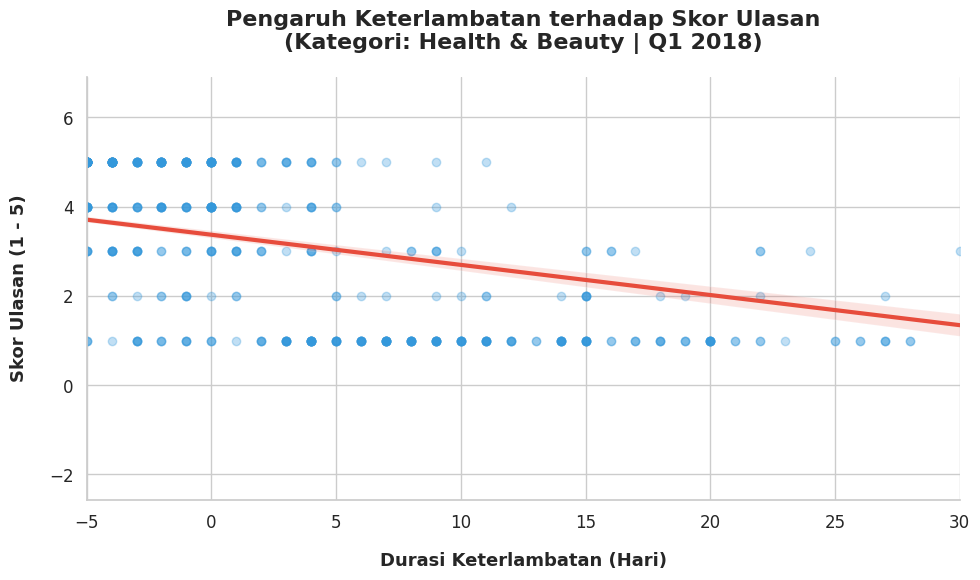



Menampilkan Grafik 2...


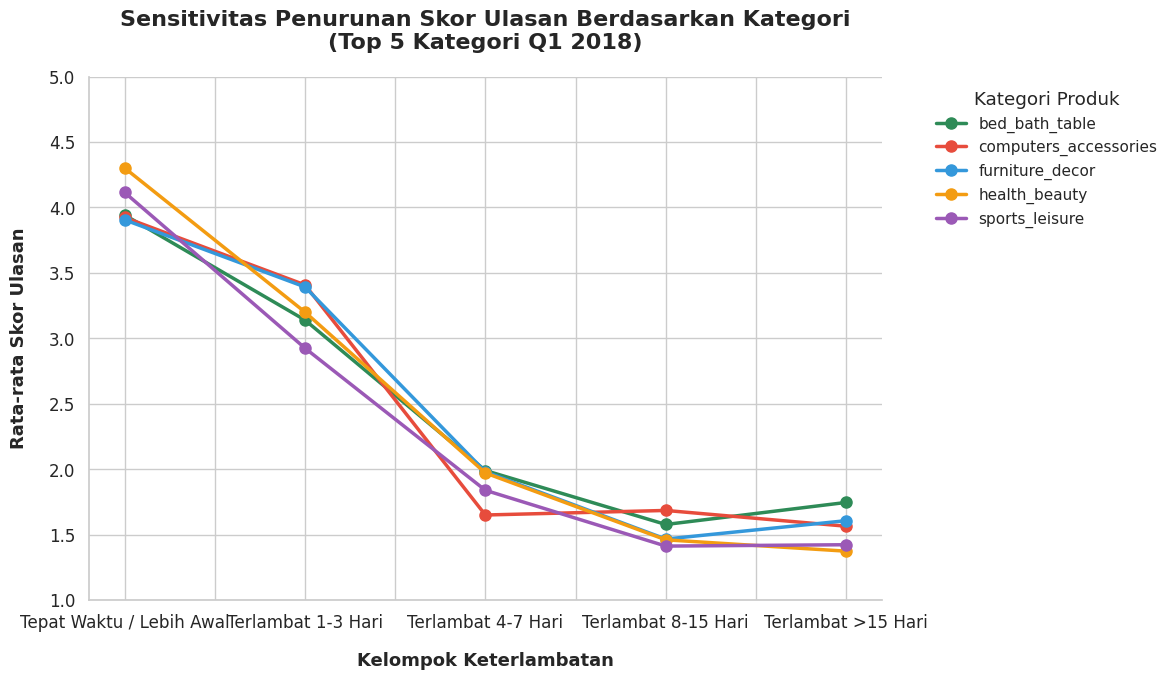

In [27]:
# =======================================================
# VISUALISASI 1: Tren Penurunan Skor (Health & Beauty)
# =======================================================
def plot_health_beauty_delay(df):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Membuat scatter plot dengan garis regresi
    sns.regplot(
        x='delay_days',
        y='review_score',
        data=df,
        scatter_kws={'alpha': 0.3, 'color': '#3498DB'}, # Biru transparan untuk sebaran data
        line_kws={'color': '#E74C3C', 'linewidth': 3},  # Merah tebal untuk garis tren
        ax=ax
    )

    ax.set_title('Pengaruh Keterlambatan terhadap Skor Ulasan\n(Kategori: Health & Beauty | Q1 2018)',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Durasi Keterlambatan (Hari)', fontsize=13, fontweight='bold', labelpad=15)
    ax.set_ylabel('Skor Ulasan (1 - 5)', fontsize=13, fontweight='bold', labelpad=15)

    # Membatasi sumbu X dari -5 (lebih awal) hingga 30 hari agar fokus pada area data utama
    ax.set_xlim(-5, 30)

    sns.despine()
    plt.tight_layout()
    return fig

# =======================================================
# VISUALISASI 2: Perbandingan Sensitivitas Kategori
# =======================================================
def plot_category_sensitivity(pivot_table):
    fig, ax = plt.subplots(figsize=(12, 7))

    # Palet warna untuk 5 kategori
    colors = ['#2E8B57', '#E74C3C', '#3498DB', '#F39C12', '#9B59B6']

    # Transpose pivot table agar delay_group menjadi sumbu X
    pivot_table.T.plot(
        marker='o',
        linewidth=2.5,
        markersize=8,
        ax=ax,
        color=colors
    )

    ax.set_title('Sensitivitas Penurunan Skor Ulasan Berdasarkan Kategori\n(Top 5 Kategori Q1 2018)',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Kelompok Keterlambatan', fontsize=13, fontweight='bold', labelpad=15)
    ax.set_ylabel('Rata-rata Skor Ulasan', fontsize=13, fontweight='bold', labelpad=15)

    # Mengatur batas sumbu Y sesuai rentang skor ulasan (1-5)
    ax.set_ylim(1, 5)

    # Merapikan posisi legenda agar tidak menutupi grafik
    ax.legend(title='Kategori Produk', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

    sns.despine()
    plt.tight_layout()
    return fig

# =======================================================
# MEMANGGIL FUNGSI VISUALISASI
# =======================================================
# Pastikan variabel health_beauty_df dan sensitivity_table
# sudah ada dari proses EDA sebelumnya

print("Menampilkan Grafik 1...")
fig1 = plot_health_beauty_delay(health_beauty_df)
plt.show()

print("\n" + "="*80 + "\n")

print("Menampilkan Grafik 2...")
fig2 = plot_category_sensitivity(sensitivity_table)
plt.show()

Insight Pengaruh Keterlambatan Pengiriman

Berdasarkan kedua visualisasi di atas, kita dapat menyimpulkan pola perilaku pelanggan terkait operasional pengiriman:

- Tren Penurunan Skor pada Kategori Health and Beauty: Pada grafik scatter plot, garis tren regresi yang berwarna merah menukik tajam ke bawah. Ini membuktikan secara visual bahwa semakin lama waktu keterlambatan dalam hitungan hari, skor kepuasan pelanggan pada produk kesehatan dan kecantikan akan semakin merosot secara pasti.

- Sensitivitas Kategori Kesehatan dan Kecantikan: Pada grafik garis, kategori health and beauty (garis kuning) menunjukkan rata rata skor paling memuaskan yakni di atas 4,0 saat pengiriman tepat waktu atau lebih awal. Namun, saat barang terlambat lebih dari dua minggu, garis ini terjun bebas menjadi yang terendah mendekati angka 1,3. Hal ini menegaskan ekspektasi tinggi pembeli pada kategori ini.

- Batas Kritis Toleransi Pelanggan: Seluruh grafik garis dari kelima kategori teratas menunjukkan titik jatuh yang sangat mirip. Skor ulasan masih berada di batas cukup aman (berkisar di angka 3,0) ketika pesanan terlambat 1 hingga 3 hari. Namun begitu masuk ke kelompok terlambat 4 hingga 7 hari, seluruh skor langsung anjlok drastis ke bawah angka 2,0. Dapat disimpulkan secara bisnis bahwa batas maksimal toleransi keterlambatan logistik adalah 3 hari.

## Analisis Lanjutan (Opsional)

Geospatial Analysis: Peta Sebaran Pelanggan
Tujuan: Mengidentifikasi distribusi dan konsentrasi lokasi geografis pelanggan e-commerce di negara Brazil menggunakan data koordinat (latitude dan longitude).

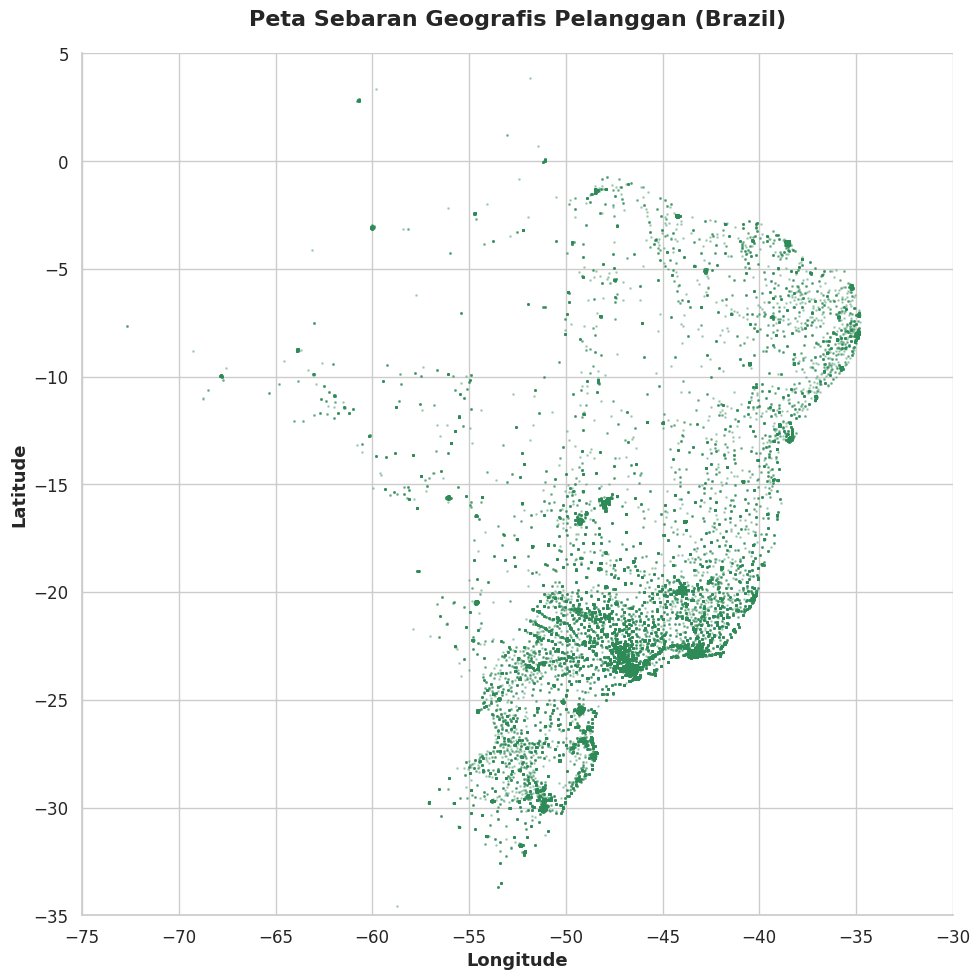

In [28]:
# =======================================================
# ANALISIS LANJUTAN: GEOSPATIAL ANALYSIS
# =======================================================
# 1. Menghapus duplikat kode pos pada data geolokasi
geo_clean = geolocation.drop_duplicates(subset='geolocation_zip_code_prefix').copy()

# 2. Menggabungkan data pelanggan dengan data geolokasi
customer_geo = customers.merge(
    geo_clean,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='inner'
)

# 3. Membuat visualisasi peta sebaran (Scatter Plot Koordinat)
fig, ax = plt.subplots(figsize=(10, 10))

# Menggunakan scatter plot. Karena jumlah data ratusan ribu, ukuran titik (s) dibuat sangat kecil
ax.scatter(
    customer_geo['geolocation_lng'],
    customer_geo['geolocation_lat'],
    alpha=0.3,
    s=1,
    c='#2E8B57' # Warna Hijau
)

ax.set_title('Peta Sebaran Geografis Pelanggan (Brazil)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=13, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=13, fontweight='bold')

# Membatasi koordinat hanya pada area negara Brazil untuk menghilangkan outlier
ax.set_xlim(-75, -30)
ax.set_ylim(-35, 5)

sns.despine()
plt.tight_layout()
plt.show()

Insight Geospatial Analysis

Dari visualisasi peta sebaran koordinat pelanggan di atas, kita dapat melihat pola distribusi demografis yang sangat jelas:

- Konsentrasi Pelanggan Tertinggi: Kumpulan titik hijau yang paling padat berada di wilayah Tenggara (Southeast) dan Selatan (South) Brazil. Area ini merupakan representasi dari kota-kota metropolitan besar dan pusat ekonomi seperti Sao Paulo dan Rio de Janeiro.

- Kesenjangan Penetrasi Pasar: Wilayah Utara (North) dan Barat Tengah (Center-West) memiliki sebaran titik yang sangat renggang. Hal ini menunjukkan bahwa penetrasi pasar e-commerce di wilayah tersebut masih sangat rendah, yang mungkin disebabkan oleh kendala infrastruktur logistik atau populasi yang lebih sedikit.

- Peluang Logistik: Tingginya konsentrasi pelanggan di wilayah Tenggara dapat dijadikan alasan kuat untuk membangun pusat distribusi utama (gudang logistik) di area tersebut. Hal ini akan mempercepat waktu pengiriman dan menekan biaya ongkos kirim secara drastis untuk mayoritas pesanan.

## Conclusion & Recommendation

Berdasarkan seluruh proses analisis data yang telah dilakukan, kita dapat menarik kesimpulan utama untuk menjawab pertanyaan bisnis:

- Kesimpulan Pertanyaan 1 (Segmentasi Pelanggan RFM):
Segmen Loyal dan Champions merupakan penggerak utama bisnis perusahaan. Meskipun jumlah gabungan orangnya hanya sekitar 50 persen dari total pelanggan, mereka mampu menyumbang nyaris 68 persen dari total perputaran uang. Segmen Champions terbukti sangat efisien dalam berbelanja. Di sisi lain, terdapat 34 persen pelanggan di segmen Potential yang pertumbuhannya masih stagnan dan belum dioptimalkan frekuensi pembelanjaannya.

- Kesimpulan Pertanyaan 2 (Pengaruh Keterlambatan Pengiriman):
Keterlambatan pengiriman terbukti secara pasti merusak kepuasan pelanggan. Batas maksimal toleransi keterlambatan yang bisa diterima oleh pelanggan adalah 3 hari. Mulai dari hari ke-4, rata-rata skor ulasan di berbagai kategori utama langsung hancur di bawah angka 2,0. Produk kesehatan dan kecantikan (health and beauty) merupakan kategori yang paling sensitif dan tidak menoleransi isu keterlambatan logistik ini.

- Kesimpulan Analisis Lanjutan (Geospasial):
Distribusi pelanggan tidak merata dan sangat terkonsentrasi di wilayah Tenggara dan Selatan Brazil, yang merupakan pusat metropolitan seperti Sao Paulo dan Rio de Janeiro.

**Rekomendasi Action Item:**
## Rekomendasi Action Item

Berangkat dari kesimpulan di atas, berikut adalah rekomendasi tindakan nyata yang dapat diimplementasikan oleh pemangku kepentingan (stakeholder) perusahaan:

- Tindakan 1 (Program Retensi VIP):
Luncurkan program loyalitas eksklusif seperti jalur layanan pelanggan VIP, akses pengiriman prioritas, atau kuota gratis ongkir bulanan khusus untuk pelanggan di segmen Champions dan Loyal guna menjaga kenyamanan kelompok penyumbang pendapatan terbesar ini.

- Tindakan 2 (Kampanye Upselling Segmen Potential):
Kirimkan kampanye promosi terpersonalisasi melalui email atau notifikasi aplikasi untuk 34 persen pelanggan di segmen Potential. Pemberian diskon produk pelengkap (cross-selling) dapat mendorong frekuensi belanja mereka agar naik kelas menjadi segmen Loyal.

- Tindakan 3 (Pengetatan Standar Waktu Pengiriman):
Terapkan pemantauan logistik yang sangat ketat untuk pengiriman pesanan pada kategori sensitif seperti produk kesehatan dan kecantikan. Pastikan mitra kurir memprioritaskan paket ini agar tidak ada yang terlambat melewati batas toleransi 3 hari.

- Tindakan 4 (Sistem Kompensasi Keterlambatan Otomatis):
Bangun fitur notifikasi otomatis pada aplikasi. Jika sistem mendeteksi sebuah paket akan terlambat memasuki hari ke-4, sistem harus otomatis mengirimkan pesan permohonan maaf beserta voucher diskon kompensasi. Hal ini terbukti secara psikologis dapat mencegah pelanggan memberikan skor ulasan bintang 1.

- Tindakan 5 (Optimasi Infrastruktur Gudang):
Gunakan data konsentrasi pelanggan di wilayah Tenggara dan Selatan Brazil sebagai landasan kuat untuk membangun atau memperluas kapasitas pusat distribusi (fulfillment center) di area tersebut. Langkah operasional ini akan secara drastis mempercepat waktu pengiriman dan mencegah terjadinya masalah keterlambatan massal.